**Sentiment prediction**

This guide will enable you to apply sentiment analysis to business problems. You will understand how to use text classification techniques to create a sentiment analysis model and will be able to apply sentiment models to real-world data. You will experiment with different vectorization and model-building techniques using popular Python libraries such as scikit-learn and gensim. You will use both count-based vectorizations and word embeddings and understand the advantages and disadvantages of each.

In [28]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import random
from wordcloud import WordCloud, STOPWORDS
from pylab import rcParams
from nltk import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
rcParams['figure.figsize'] = 30, 60
%matplotlib inline

**Context:** As a data scientist for a large e-commerce company, you have tens of thousands of customers who write product reviews every day. Each review contains text comments along with a 1-to-5-star rating system (1 being the least satisfied and 5 being the most satisfied). You also have a customer service team that interacts with customers through phone and messaging services. Your company also collects feedback on your customers' experiences with the website after each purchase. Neither this feedback nor the messaging service has a rating. The company wants to quantify customer satisfaction derived from these unrated interactions to help with future business decisions (e.g., determining how well your various customer service agents are performing).

**Problem:** The task is to build models that can identify the sentiment (positive or negative) of each of these unrated interactions.

**The case is structured as follows:**

**1)** Read and analyze the input text data and the corresponding response variables (ratings);

**2)** Perform basic preprocessing to prepare the data for modeling;

**3)** Learn and apply various methods for highlighting review text;

**4)** Build machine learning models to classify the text as expressing positive or negative sentiment (1 or 0).

In [29]:
records_in_file = 568454 #number of records in file
sample_size = 5000 #desired sample size
filename = "Reviews.csv"
random.seed(101) # initialize the random number generator.
skip = sorted(random.sample(range(1,records_in_file+1),records_in_file-sample_size))
amazon_reviews = pd.read_csv(filename, skiprows=skip)
# Selecting just 5,000 records for faster computation and low memory usage.
# Feel free to edit the above lines of code later to build ML models using all the data.
amazon_reviews.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
1,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,1166313600,Good Instant,This is a good instant oatmeal from the best o...
2,36,B001EO5QW8,A2CI0RLADCRKPF,T. J. Ryan,3,3,4,1210464000,satisfying,"McCann's Instant Irish Oatmeal, Variety Pack o..."
3,618,B000G6RYNE,ABCXJIXC6Q6EB,Arthur Kang,3,4,5,1194307200,awesome chips,these are the best chips out there.. nothing c...
4,639,B000G6RYNE,A2W1A5GK4A03ZT,"M. Gonzales ""emelgee""",0,0,5,1336262400,GREAT DEAL,I knew my family already liked these chips so ...


Distribution of the number of words per review:

np.float64(82.3736)

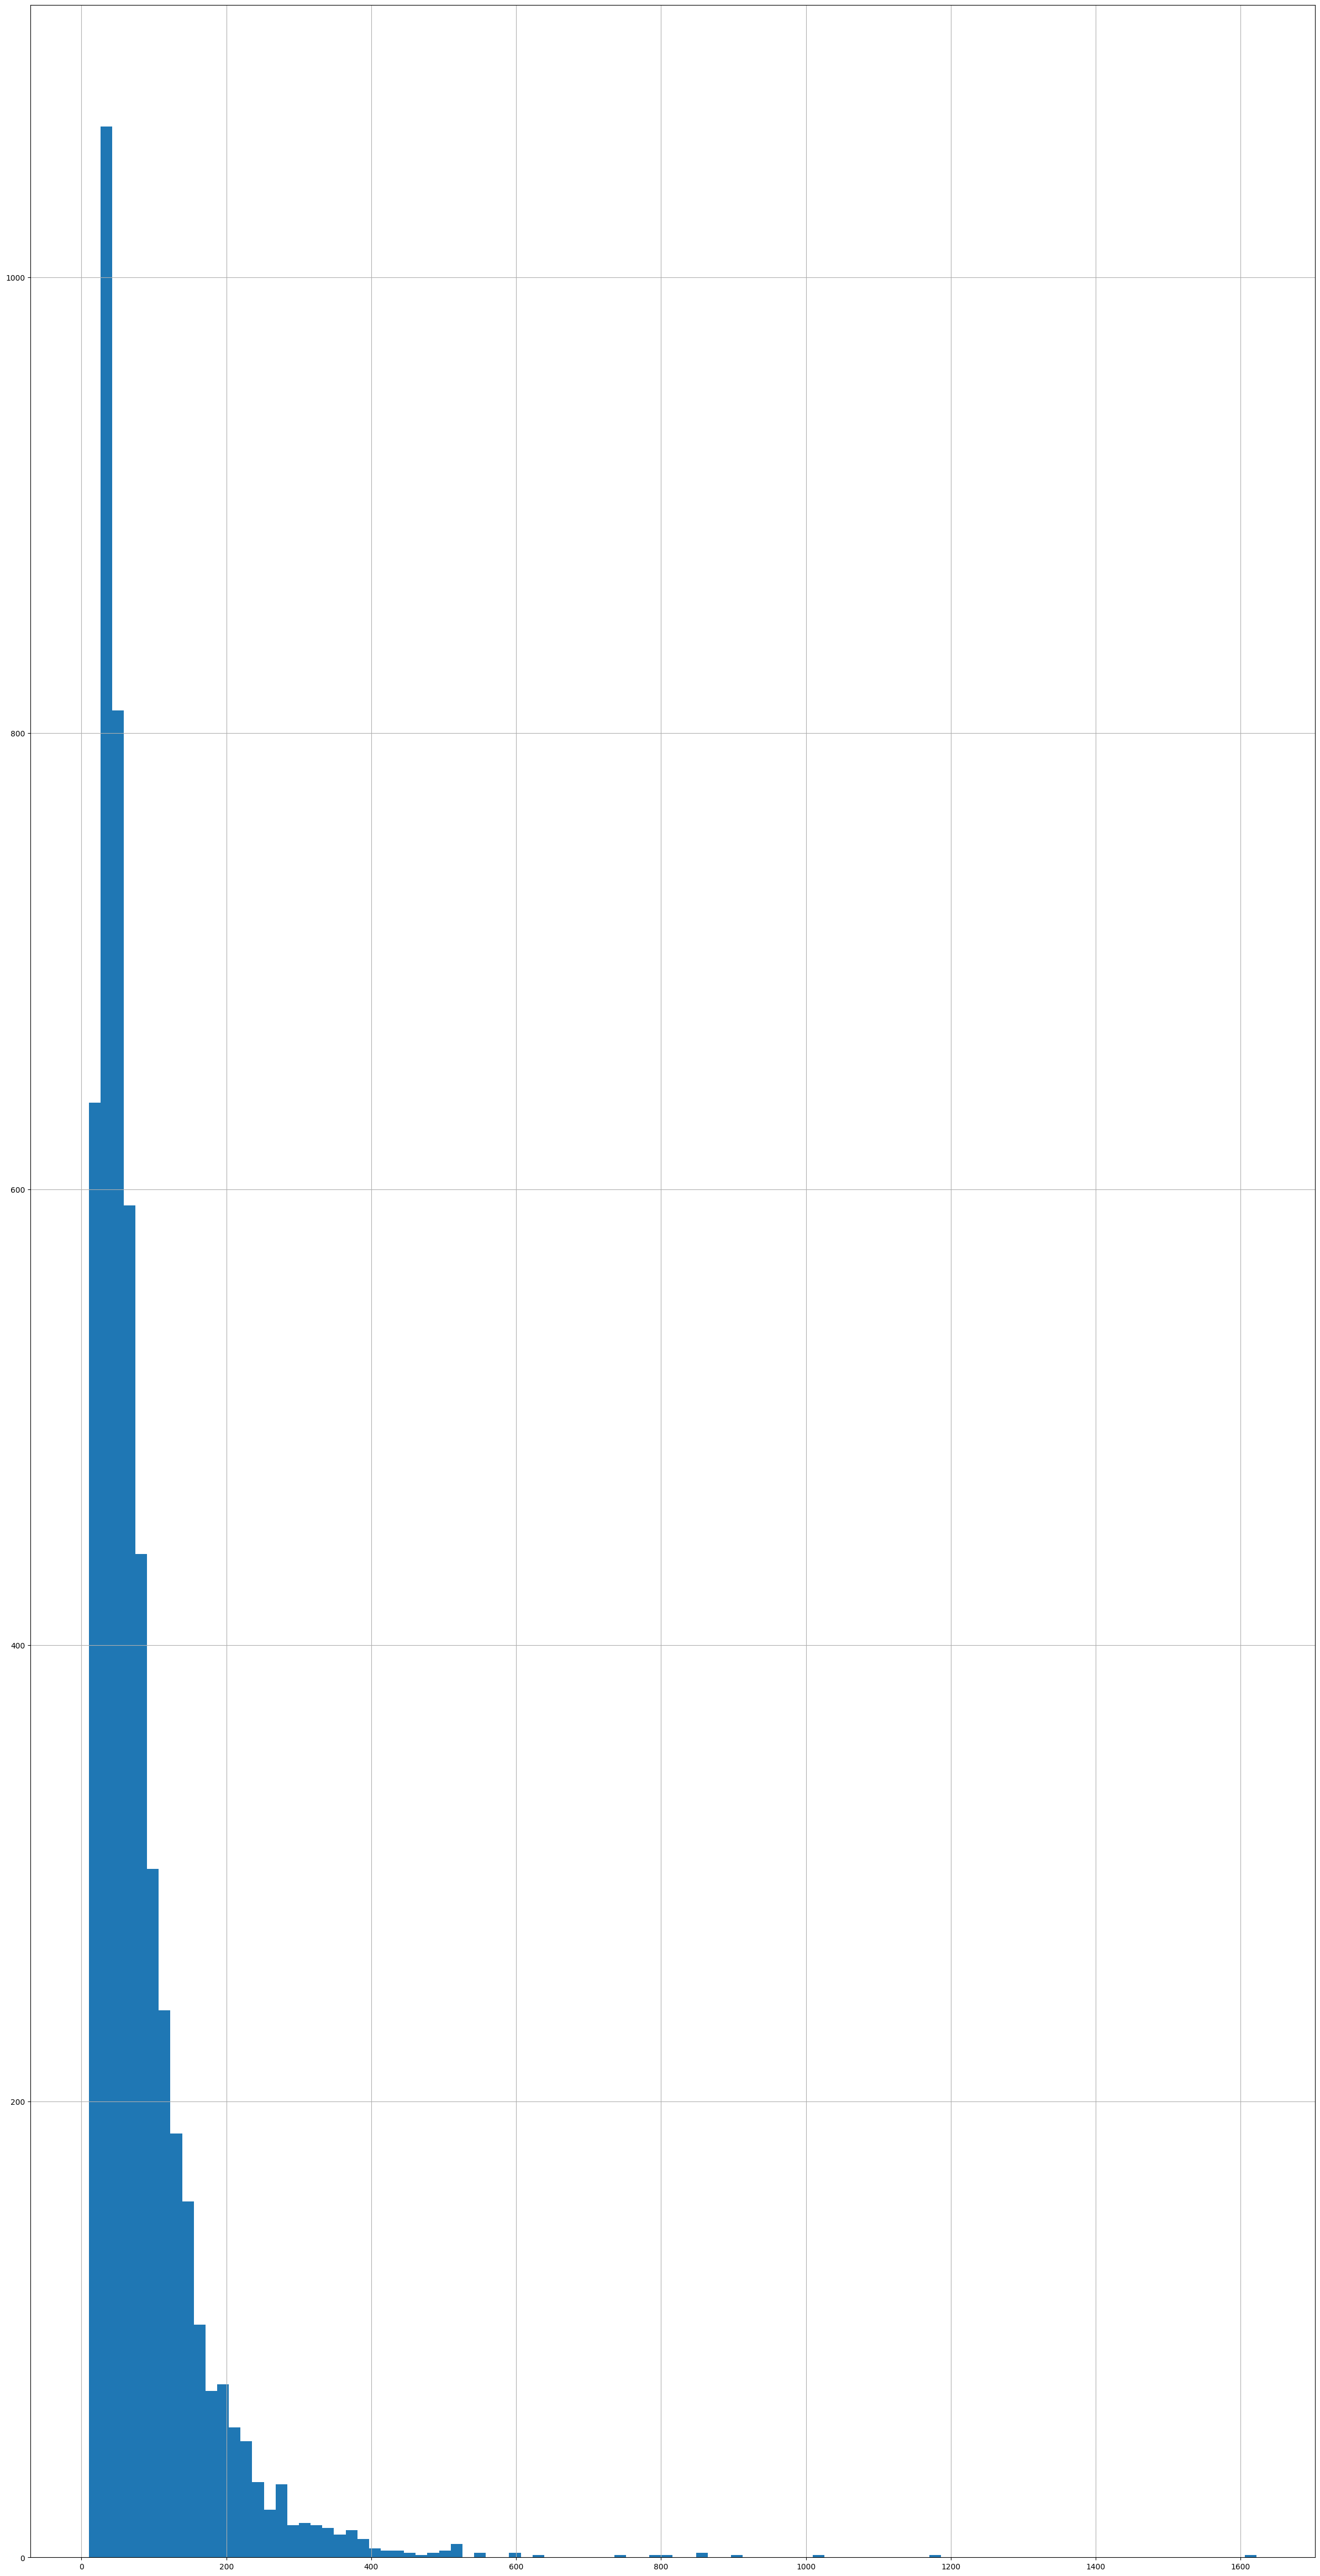

In [30]:
# Getting the number of words by splitting them by a space
words_per_review = amazon_reviews.Text.apply(lambda x: len(x.split(" ")))
words_per_review.hist(bins = 100)

words_per_review.mean()

Grade distribution:

In [31]:
amazon_reviews.Score.value_counts()

Score
5    3161
4     739
1     454
3     389
2     257
Name: count, dtype: int64

In [32]:
percent_val = 100 * amazon_reviews.Score.value_counts()/amazon_reviews.shape[0]
percent_val

Score
5    63.22
4    14.78
1     9.08
3     7.78
2     5.14
Name: count, dtype: float64

<Axes: xlabel='Score'>

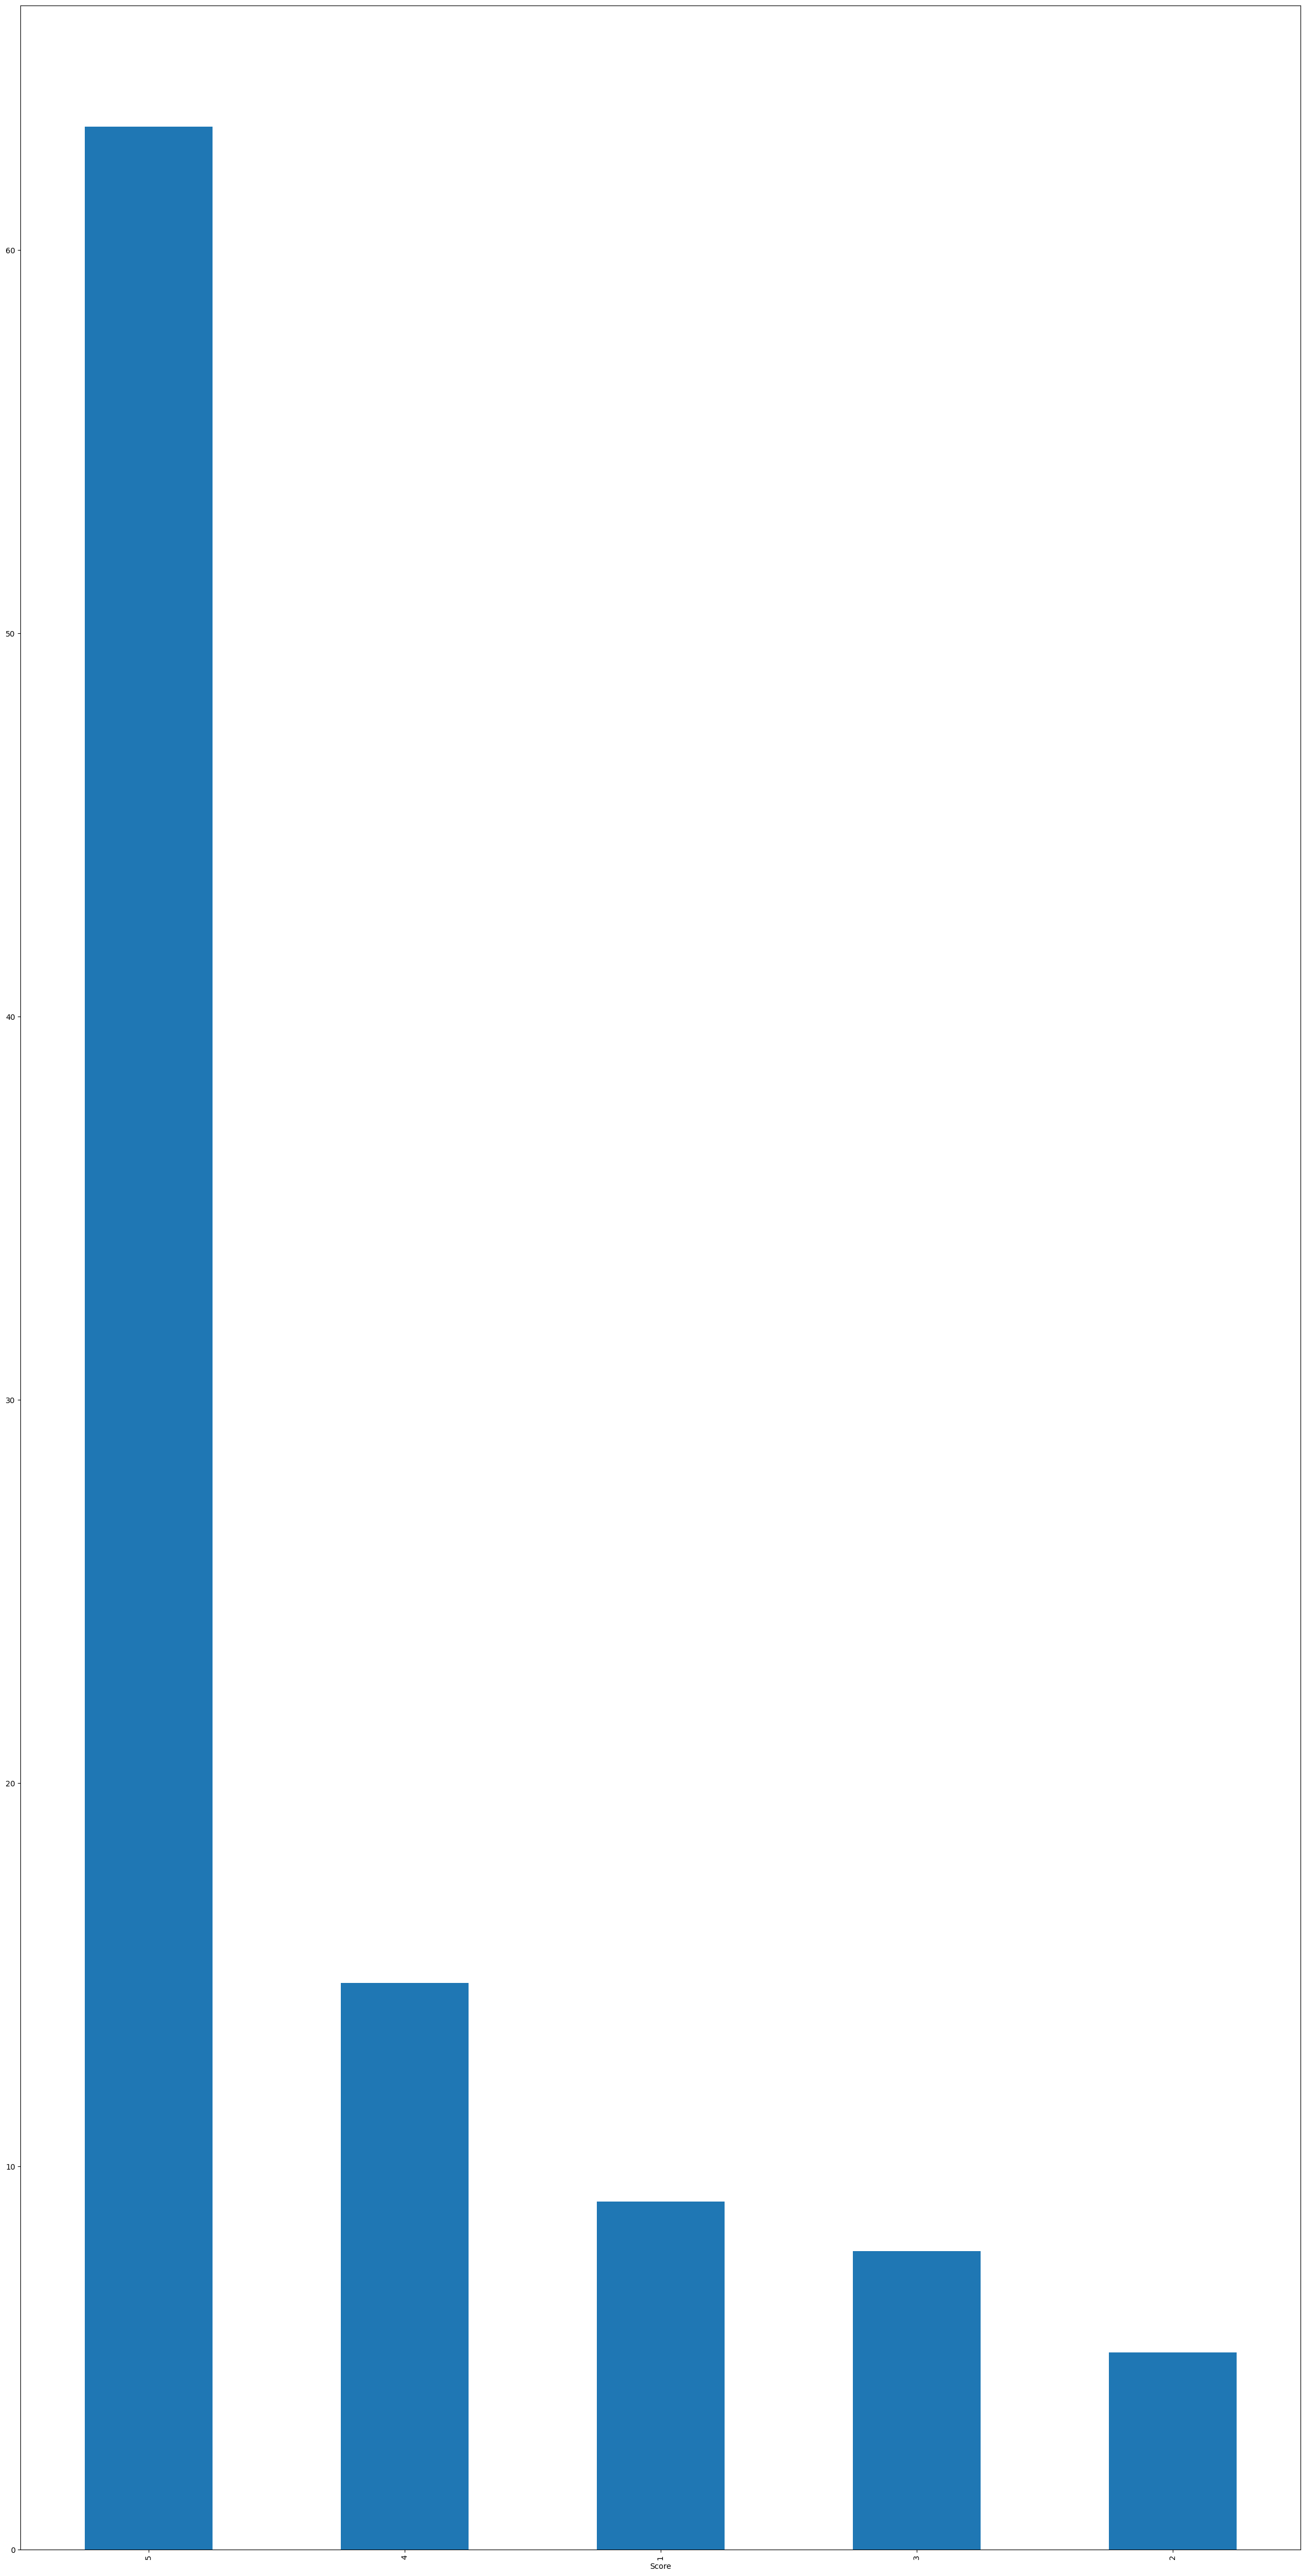

In [33]:
percent_val.plot.bar()

**Exercise 1**
Create a word cloud for the product reviews.

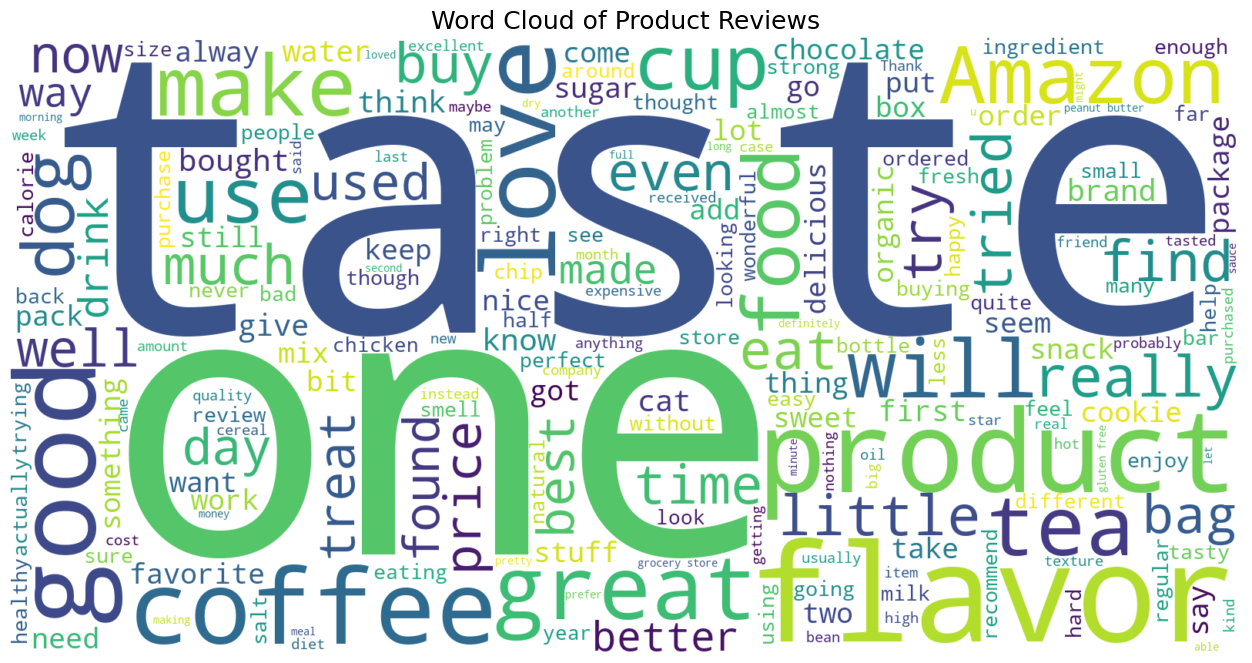

In [34]:
# Ensure the reviews text exists
assert 'amazon_reviews' in globals(), "The dataframe 'amazon_reviews' is not defined. Please run the data loading cell above."
assert 'Text' in amazon_reviews.columns, "Expected a 'Text' column in amazon_reviews."

# Prepare text and stopwords
text_series = amazon_reviews['Text'].dropna().astype(str)
corpus = " ".join(text_series.values)

extra_stopwords = {"br", "href", "http", "https", "www", "com", "amp"}
stopwords = STOPWORDS.union(extra_stopwords)

# Generate word cloud
wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(corpus)

# Plot
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Product Reviews', fontsize=18)
plt.show()

**Standardization of ratings for sentiment analysis**

For the purposes of sentiment analysis, we will convert all of the ratings into binary values using the follow rule: ratings of 4 or 5 will get mapped to 1 (indicating
"positive"), ratings of 1 or 2 will get mapped to 0 (indicating "negative"), and ratings of 3 will get removed.

In [35]:
amazon_reviews['Sentiment_rating'] = np.where(amazon_reviews.Score > 3, 1, 0)
amazon_reviews['Sentiment_rating'].value_counts()

Sentiment_rating
1    3900
0    1100
Name: count, dtype: int64

In [36]:
# Removing neutral reviews
amazon_reviews = amazon_reviews[amazon_reviews.Score != 3]
amazon_reviews['Sentiment_rating'].value_counts()

Sentiment_rating
1    3900
0     711
Name: count, dtype: int64

<Axes: xlabel='Sentiment_rating'>

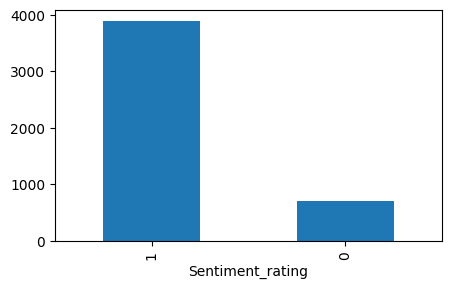

In [37]:
rcParams['figure.figsize'] = 5, 3
amazon_reviews.Sentiment_rating.value_counts().plot.bar()

**Preprocessing**

Text preprocessing and normalization are crucial before building a suitable NLP model. Some important steps include:

**1.** Converting words to lowercase/uppercase

**2.** Removing special characters

**3.** Removing stop words and high- and low-frequency words

**4.** Stemming/lemmatization

**Paso 1: Convert all text to lowercase/uppercase**

In [38]:
amazon_reviews['reviews_text_new'] = amazon_reviews.Text.apply(lambda x: x.lower())

In [39]:
from nltk import word_tokenize
import nltk

nltk.download('punkt')
token_lists = [word_tokenize(each) for each in amazon_reviews.Text]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))
token_lists_lower = [word_tokenize(each) for each in amazon_reviews.reviews_text_new]
tokens_lower = [item for sublist in token_lists_lower for item in sublist]

print("Number of unique tokens now: ", len(set(tokens_lower)))

[nltk_data] Downloading package punkt to C:\Users\Ismenia
[nltk_data]     Guevara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Number of unique tokens then:  20598
Number of unique tokens now:  17083


**Exercise 2**
Is removing special characters even a good idea? What are some examples of characters that would likely be safe to remove, and what are some that would not be?

Yes, it's generally advisable to remove some special characters during sentiment prediction, as many of them don't provide useful information and only create noise in the data. For example, symbols like #, %, $, &, or repeated characters like “!!!” or “???” can be safely removed since they don't change the meaning of the text. However, not all characters should be removed, as some convey emotions or important context, such as exclamation and question marks, emojis, or hashtags on social media, which can directly influence the interpretation of the expressed sentiment.

**Paso 2: Remove special characters**

In [40]:
# Selecting non alpha numeric charactes that are not spaces
special_chars = amazon_reviews.reviews_text_new.apply(lambda x: [each for each in list(x) if not each.isalnum() and each
!= ' '])
# Getting list of list into a single list
flat_list = [item for sublist in special_chars for item in sublist]
# Unique special characters
print(set(flat_list))

{'@', '`', '®', '-', '/', '\\', '.', '|', '§', '&', '(', '_', ';', '+', ']', '"', '?', '#', ',', '!', '^', '{', ':', '}', '>', ')', '<', '$', "'", '%', '=', '*', '[', '~'}


In [41]:
import re
review_backup = amazon_reviews.reviews_text_new.copy()
amazon_reviews.reviews_text_new = amazon_reviews.reviews_text_new.apply(
lambda x: re.sub('[^A-Za-z0-9 ]+', ' ', x)
)

Comparison of the text before and after removing special characters:

In [42]:
print("Old Review:")
review_backup.iloc[2]

Old Review:


"mccann's instant irish oatmeal, variety pack of regular, apples & cinnamon, and maple & brown sugar, 10-count boxes (pack of 6)<br /><br />i'm a fan of the mccann's steel-cut oats, so i thought i'd give the instant variety a try. i found it to be a hardy meal, not too sweet, and great for folks like me (post-bariatric surgery) who need food that is palatable, easily digestible, with fiber but won't make you bloat."

In [43]:
print("New Review:")
amazon_reviews.reviews_text_new.iloc[2]

New Review:


'mccann s instant irish oatmeal  variety pack of regular  apples   cinnamon  and maple   brown sugar  10 count boxes  pack of 6 br  br  i m a fan of the mccann s steel cut oats  so i thought i d give the instant variety a try  i found it to be a hardy meal  not too sweet  and great for folks like me  post bariatric surgery  who need food that is palatable  easily digestible  with fiber but won t make you bloat '

Comparison of token count before and after the cleanup:

In [44]:
token_lists = [word_tokenize(each) for each in amazon_reviews.Text]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))
token_lists = [word_tokenize(each) for each in amazon_reviews.reviews_text_new]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens now: ", len(set(tokens)))

Number of unique tokens then:  20598
Number of unique tokens now:  14315


**Paso 3: Remove stop words and high- and low-frequency words**

In [45]:
import nltk
nltk.download('stopwords')
noise_words = []

stopwords_corpus = nltk.corpus.stopwords
eng_stop_words = stopwords_corpus.words('english')
noise_words.extend(eng_stop_words)
print(len(noise_words))
noise_words

198


[nltk_data] Downloading package stopwords to C:\Users\Ismenia
[nltk_data]     Guevara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

**Exercise 3**

Find the high- and low-frequency words, which we will define as the 1% of words that occur most often in the reviews, as well as define the 1% of words that occur
least often in the reviews (after adjusting for case and special characters). Ensure that, Stop words and high/low frequency words have now been added
to noise_words, which will be removed from the reviews prior to training machine learning models. At this point, print the total of resulting tokens.

In [46]:
# Exercise 3: añadir top/bottom 1% de palabras frecuentes a noise_words y crear filtered_text
import math
import nltk
from collections import Counter
nltk.download('punkt', quiet=True)

# Validaciones básicas
assert 'amazon_reviews' in globals(), "Falta amazon_reviews (ejecuta la celda de lectura)."
assert 'reviews_text_new' in amazon_reviews.columns, "Falta reviews_text_new (ejecuta pasos 1 y 2)."

# Tokenizar texto ya normalizado y sin caracteres especiales
token_lists_clean = [nltk.word_tokenize(txt) for txt in amazon_reviews.reviews_text_new.fillna("")]
all_tokens = [tok for sub in token_lists_clean for tok in sub]
frecuencias = Counter(all_tokens)
unique_total = len(frecuencias)

portion = 0.01  # 1%
n_top = max(1, math.ceil(portion * unique_total))
n_bottom = max(1, math.ceil(portion * unique_total))

# Ordenar por frecuencia
orden_desc = sorted(frecuencias.items(), key=lambda x: (-x[1], x[0]))
orden_asc = sorted(frecuencias.items(), key=lambda x: (x[1], x[0]))

high_freq_words = [w for w,_ in orden_desc[:n_top]]
low_freq_words = [w for w,_ in orden_asc[:n_bottom]]

print(f"Tokens únicos totales: {unique_total}")
print(f"Ejemplo top 1% ({n_top}): {high_freq_words[:15]}")
print(f"Ejemplo bottom 1% ({n_bottom}): {low_freq_words[:15]}")

# Inicializar noise_words si no existe
if 'noise_words' not in globals():
    noise_words = []

# Unir conjuntos
noise_words = set(noise_words)
noise_words.update(high_freq_words)
noise_words.update(low_freq_words)
print(f"Total noise_words (stopwords + high + low): {len(noise_words)}")

# Filtrar
token_lists_filtered = [[tok for tok in toks if tok not in noise_words] for toks in token_lists_clean]
flat_filtered = [tok for sub in token_lists_filtered for tok in sub]
unique_filtered = set(flat_filtered)

amazon_reviews['filtered_text'] = [" ".join(toks) for toks in token_lists_filtered]

print("==== Métricas ====")
print(f"Total tokens originales: {len(all_tokens)}")
print(f"Tokens únicos originales: {unique_total}")
print(f"Total tokens filtrados: {len(flat_filtered)}")
print(f"Tokens únicos filtrados: {len(unique_filtered)}")

print("\nEjemplo antes:")
print(amazon_reviews.reviews_text_new.iloc[0][:300])
print("\nEjemplo después:")
print(amazon_reviews.filtered_text.iloc[0][:300])

Tokens únicos totales: 14315
Ejemplo top 1% (144): ['the', 'i', 'and', 'a', 'it', 'to', 'of', 'is', 'this', 'br', 'in', 'for', 'my', 'that', 'you']
Ejemplo bottom 1% (144): ['0312377428', '03430', '0790700506', '0825305845', '0mg', '1000000', '100g', '100mg', '103', '10504', '10ib', '10min', '10mins', '10th', '10x']
Total noise_words (stopwords + high + low): 405
==== Métricas ====
Total tokens originales: 383034
Tokens únicos originales: 14315
Total tokens filtrados: 144747
Tokens únicos filtrados: 13957

Ejemplo antes:
product arrived labeled as jumbo salted peanuts the peanuts were actually small sized unsalted  not sure if this was an error or if the vendor intended to represent the product as  jumbo 

Ejemplo después:
arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent jumbo


**Paso 4: Stemming/Lemmatization**

In [47]:
from nltk.stem import PorterStemmer, WordNetLemmatizer, LancasterStemmer
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet
porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to C:\Users\Ismenia
[nltk_data]     Guevara\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Ismenia
[nltk_data]     Guevara\AppData\Roaming\nltk_data...


**Building machine learning models**

In [48]:
amazon_reviews[['Text','Score','Sentiment_rating']].head(5)

,Text,Score,Sentiment_rating
0,Product arrived labeled as Jumbo Salted Peanut...,1,0
1,This is a good instant oatmeal from the best o...,4,1
2,"McCann's Instant Irish Oatmeal, Variety Pack o...",4,1
3,these are the best chips out there.. nothing c...,5,1
4,I knew my family already liked these chips so ...,5,1


**Paso 1: Bag-of-words**

In [49]:
# Creating a method for stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
analyzer = CountVectorizer().build_analyzer()

def stemmed_words(doc):
	# ensure doc is string to avoid errors for NaN or non-str inputs
	return (stemmer.stem(w) for w in analyzer(str(doc)))

In [52]:
# Creating a python object of the class CountVectorizer
bow_counts = CountVectorizer(
tokenizer=word_tokenize,
stop_words=noise_words,
ngram_range=(1, 1)
)

In [53]:
reviews_train, reviews_test = train_test_split(amazon_reviews, test_size=0.2, random_state=0)
# Ensure CountVectorizer receives a list (not a set) for stop_words
if 'noise_words' in globals() and isinstance(noise_words, set):
    bow_counts.set_params(stop_words=list(noise_words))

X_train_bow = bow_counts.fit_transform(reviews_train.reviews_text_new)
X_test_bow = bow_counts.transform(reviews_test.reviews_text_new)

c:\Users\Ismenia Guevara\Documents\Repositorios GIT\PracticasBigData\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Ismenia Guevara\Documents\Repositorios GIT\PracticasBigData\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'might', 'must', "n't", 'need', 'sha', 'wo'] not in stop_words.
  warnings.warn(


In [54]:
y_train_bow = reviews_train['Sentiment_rating']
y_test_bow = reviews_test['Sentiment_rating']
y_test_bow.value_counts() / y_test_bow.shape[0]

Sentiment_rating
1    0.84182
0    0.15818
Name: count, dtype: float64

**Paso 2: Applying logistic regression**

In [55]:
# Training the model
lr_model_all = LogisticRegression(C=1, solver="liblinear")
lr_model_all.fit(X_train_bow, y_train_bow)
# Predicting the output
test_pred_lr_prob = lr_model_all.predict_proba(X_test_bow)
test_pred_lr_all = lr_model_all.predict(X_test_bow)
print("F1 score: ", f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)

F1 score:  0.9340796019900498
Accuracy:  88.51570964247021


In [56]:
probabilities = [each[1] for each in test_pred_lr_prob]
predictions = pd.DataFrame()
predictions['Text'] = reviews_test['Text']
predictions['Actual_Score'] = reviews_test['Score']
predictions['Sentiment_rating'] = reviews_test['Sentiment_rating']
predictions['Predicted_sentiment'] = test_pred_lr_all
predictions['Predicted_probability'] = probabilities

predictions.head(5)

,Text,Actual_Score,Sentiment_rating,Predicted_sentiment,Predicted_probability
2719,I honestly wish the other reviewer would have ...,5,1,1,0.999414
3602,Butterfinger hot chocolate is very good. It ta...,5,1,1,0.966388
409,These are so tasty and just the right amount o...,5,1,1,0.997060
3341,"Salsa Verde is my favorite Doritos flavor, but...",5,1,1,0.999845
3108,"As a Native American who is from Seattle, I wa...",1,0,0,0.029634


In [57]:
accuracy_score(predictions['Sentiment_rating'], predictions['Predicted_sentiment'])

0.8851570964247021

**Paso 3: TF-IDF Model**

In [59]:
# Create a vectorizer - we still feed in our stop words, although
# these are less relevant now as TF-IDF would weight them less
# anyway.
tfidf_counts = TfidfVectorizer(
tokenizer=word_tokenize,
stop_words=noise_words,
ngram_range=(1,1)
)
# Asegurar que stop_words sea lista
stop_words_tfidf = list(noise_words) if isinstance(noise_words, set) else noise_words

tfidf_counts = TfidfVectorizer(
    tokenizer=word_tokenize,
    stop_words=stop_words_tfidf,
    ngram_range=(1,1)
)

X_train_tfidf = tfidf_counts.fit_transform(reviews_train.reviews_text_new)
X_test_tfidf = tfidf_counts.transform(reviews_test.reviews_text_new)
X_test_tfidf = tfidf_counts.transform(reviews_test.reviews_text_new)

c:\Users\Ismenia Guevara\Documents\Repositorios GIT\PracticasBigData\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Ismenia Guevara\Documents\Repositorios GIT\PracticasBigData\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'might', 'must', "n't", 'need', 'sha', 'wo'] not in stop_words.
  warnings.warn(


**Paso 4: Applying logistic regression to TF-IDF features**

In [60]:
# Create the classifier
lr_model_tf_idf = LogisticRegression(solver="liblinear")
# Train the classifier
lr_model_tf_idf.fit(X_train_tfidf, y_train_bow)
# Predict the results
test_pred_lr_prob = lr_model_tf_idf.predict_proba(X_test_tfidf)
test_pred_lr_all = lr_model_tf_idf.predict(X_test_tfidf)
## Evaluating the model
print("F1 score: ",f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)

F1 score:  0.9183431952662722
Accuracy:  85.04875406283857


**Word embeddings template**

In [63]:
import gensim
# Loading a pre-trained glove word embedding that is trained on a Twitter dataset
# This word embedding is 200 dimensional, meaning that each word is represented
# by a 200 dimensional vector.
model = gensim.models.KeyedVectors.load_word2vec_format(
	os.path.join(os.getcwd(), 'glove.twitter.27B.200d_out.txt'),
	binary=False,
	unicode_errors='ignore'
)

In [64]:
def print_similarity(word1, word2, model):
    v1 = model[word1]
    v2 = model[word2]
    similarity = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    print(f"{word1} and {word2} are {round(similarity * 100)}% similar")
    print_similarity("cat", "dog", model)
    print_similarity("good", "bad", model)
    print_similarity("great", "good", model)
    print_similarity("grass", "model", model)

In [66]:
# Build review embeddings by averaging word vectors per review
# Use the most processed text available
text_col = 'filtered_text' if 'filtered_text' in amazon_reviews.columns else (
	'reviews_text_new' if 'reviews_text_new' in amazon_reviews.columns else 'Text'
)

# Helper to convert a review into a fixed-size vector
def review_to_vec(text):
	tokens = word_tokenize(str(text))
	vecs = [model[w] for w in tokens if w in model]
	if vecs:
		return np.mean(vecs, axis=0)
	return np.zeros(model.vector_size, dtype=np.float32)

# Compute embeddings aligned to amazon_reviews index
review_embeddings = np.vstack([review_to_vec(t) for t in amazon_reviews[text_col].fillna("")])

embedding_data = pd.DataFrame(review_embeddings, index=amazon_reviews.index)
embedding_data = embedding_data.fillna(0)
embedding_data.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
4556,-0.234697,-0.007149,-0.027413,0.333307,-0.037147,0.164591,0.371890,-0.050192,0.032033,-0.156432,...,-0.196208,0.229601,-0.114556,0.091966,0.405017,0.133171,0.125542,0.215425,0.038281,0.096748
2332,-0.305415,-0.200143,0.000709,0.123090,-0.023754,0.086057,0.526533,-0.034195,-0.078555,-0.306262,...,-0.052500,0.022236,0.197580,0.018317,0.114997,0.168523,0.143361,0.174348,0.024788,-0.144920
2329,-0.148184,-0.053167,-0.075317,0.110085,-0.172818,0.243985,0.543414,-0.147950,-0.117112,-0.198894,...,-0.204725,0.036881,0.037848,0.148098,0.183643,0.184753,0.149193,0.213712,0.078380,-0.156443
54,-0.174315,-0.163196,-0.100244,0.045264,-0.074460,0.282600,0.470579,-0.198657,-0.024671,-0.133545,...,0.011308,0.113691,0.044719,0.051639,0.150125,-0.061310,0.069517,0.084397,0.020890,-0.110940
2216,-0.047874,-0.138262,-0.101185,0.068733,0.024458,0.147781,0.344486,-0.097889,-0.132338,-0.162715,...,-0.034110,0.007988,-0.074856,0.046069,0.202460,-0.050141,0.064872,0.061969,0.006713,-0.058853
2716,0.177340,0.107700,0.230397,-0.015271,0.059668,-0.099420,0.697937,-0.141636,0.043206,0.090119,...,0.266802,-0.006134,-0.054224,0.244826,-0.016548,0.087950,0.076371,0.180690,-0.032137,0.031771
751,-0.103180,0.155321,-0.082743,0.190522,-0.061126,0.119098,0.542395,-0.005650,-0.104471,-0.167765,...,-0.110201,0.073040,0.094938,0.037300,0.114707,-0.028201,0.108014,0.191543,0.080634,-0.006737
3851,-0.100299,-0.235404,0.100097,-0.013767,-0.048140,0.195396,0.557991,-0.300019,0.016475,-0.288106,...,-0.061789,0.112035,0.103663,0.270583,0.185970,0.130286,0.240616,0.107027,-0.044182,-0.131544
4263,-0.092593,-0.004001,0.059917,0.170120,0.001231,0.214484,0.617703,-0.131856,0.042541,-0.255277,...,-0.004442,0.157140,0.229315,0.180425,0.236334,0.027154,-0.014498,0.038191,0.235578,-0.028575
1863,-0.107766,-0.108303,0.110954,0.151334,0.018383,0.005598,0.717305,-0.126379,-0.057636,-0.139186,...,-0.084077,0.036234,-0.157979,-0.123563,0.139225,-0.046220,0.062114,0.077819,0.081089,0.015911


In [67]:
X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(
embedding_data,
amazon_reviews.Sentiment_rating,
test_size=0.2,
random_state=0
)

In [68]:
lr_model = LogisticRegression(penalty="l1", C=10, solver="liblinear")
lr_model.fit(X_train_embed, y_train_embed)
test_pred_lr_prob = lr_model.predict_proba(X_test_embed)
test_pred_lr_all = lr_model.predict(X_test_embed)
print("F1 score: ", f1_score(y_test_embed, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_embed, test_pred_lr_all)*100)

F1 score:  0.9233668341708543
Accuracy:  86.78223185265439
